<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/61_Lab1_Forecast_Inventory_Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1. Forecast → Inventory Decision
### 예측에서 재고 의사결정으로 / From Forecast to Inventory Decision

이 실습은 시계열 예측을 **의사결정 문제**로 연결합니다.  
This lab connects time-series forecasting to an **inventory decision** problem.

---
**학습목표 / Learning Objectives**
1. 주간 수요 시계열을 생성하고 구조를 이해한다.  
   Generate a weekly demand series and understand its structure.
2. Naive, Moving Average, ARIMA 예측을 비교한다.  
   Compare Naive, Moving Average, and ARIMA forecasts.
3. 예측치를 주문량으로 변환하여 재고비용을 계산한다.  
   Convert forecasts into order quantities and compute inventory costs.
4. **정확한 예측이 항상 최선의 의사결정은 아닐 수 있음**을 확인한다.  
   Verify that **the most accurate forecast is not always the best decision**.

In [1]:
# Colab 권장 설치 셀 / Recommended installation cell
!pip -q install yfinance statsmodels scipy openpyxl

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import display, Markdown

np.random.seed(42)


def bilingual_title(kr, en):
    display(Markdown(f"## {kr}<br><span style='font-size:0.9em;color:#666'>{en}</span>"))


def bilingual_text(kr, en):
    display(Markdown(f"**[KR]** {kr}<br>**[EN]** {en}"))


def summary_box(title_kr, title_en, bullets_kr, bullets_en):
    kr = '<br>'.join([f"- {x}" for x in bullets_kr])
    en = '<br>'.join([f"- {x}" for x in bullets_en])
    display(Markdown(f"### {title_kr}<br><span style='font-size:0.9em;color:#666'>{title_en}</span><br><br>**[KR]**<br>{kr}<br><br>**[EN]**<br>{en}"))

## 1. 데이터 생성<br><span style='font-size:0.9em;color:#666'>1. Generate demand data</span>

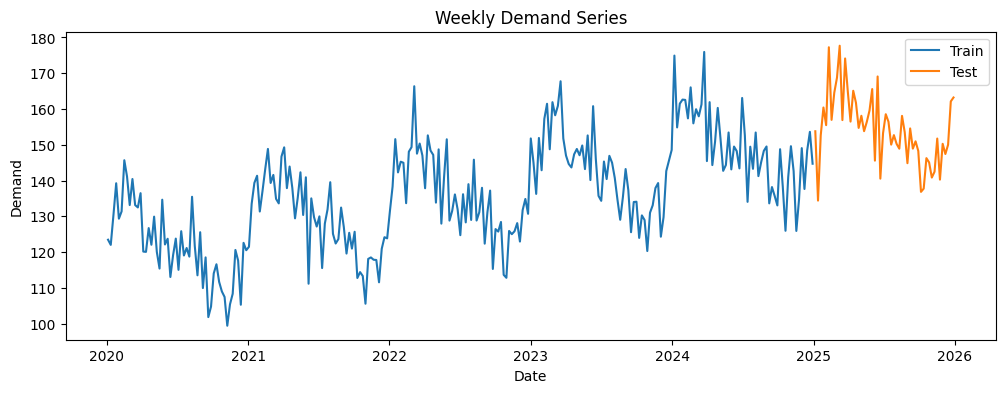

**[KR]** 총 313주 데이터를 생성했습니다. 학습 구간은 261주, 평가 구간은 52주입니다.<br>**[EN]** Generated 313 weekly observations. Training set: 261 weeks, test set: 52 weeks.

In [3]:
bilingual_title("1. 데이터 생성", "1. Generate demand data")

dates = pd.date_range('2020-01-05', '2025-12-28', freq='W')
t = np.arange(len(dates))
demand = (
    120
    + 0.12 * t
    + 12 * np.sin(2*np.pi*t/52)
    + 6 * np.sin(2*np.pi*t/26)
    + np.random.normal(0, 7, len(t))
)
demand = np.maximum(demand, 30)
ts = pd.Series(demand, index=dates, name='demand')

train = ts[:'2024-12-29']
test = ts['2025-01-05':]

plt.figure(figsize=(12,4))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Test')
plt.title('Weekly Demand Series')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

bilingual_text(
    f"총 {len(ts)}주 데이터를 생성했습니다. 학습 구간은 {len(train)}주, 평가 구간은 {len(test)}주입니다.",
    f"Generated {len(ts)} weekly observations. Training set: {len(train)} weeks, test set: {len(test)} weeks."
)

In [4]:
bilingual_title("2. 예측 함수 정의", "2. Define forecasting functions")

def rolling_forecast_naive(train, test):
    history = list(train.values)
    preds = []
    for actual in test.values:
        preds.append(history[-1])
        history.append(actual)
    return pd.Series(preds, index=test.index)

def rolling_forecast_ma(train, test, window=4):
    history = list(train.values)
    preds = []
    for actual in test.values:
        preds.append(np.mean(history[-window:]))
        history.append(actual)
    return pd.Series(preds, index=test.index)

def rolling_forecast_arima(train, test, order=(2,1,2)):
    history = list(train.values)
    preds = []
    for actual in test.values:
        model = ARIMA(history, order=order)
        fit = model.fit()
        yhat = fit.forecast(steps=1)[0]
        preds.append(yhat)
        history.append(actual)
    return pd.Series(preds, index=test.index)

## 2. 예측 함수 정의<br><span style='font-size:0.9em;color:#666'>2. Define forecasting functions</span>

## 3. 예측 실행<br><span style='font-size:0.9em;color:#666'>3. Run forecasting models</span>

,Actual,Naive,MovingAverage,ARIMA
2025-01-05,153.785657,144.711487,146.097630,147.821930
2025-01-12,134.411256,153.785657,150.130964,149.802376
2025-01-19,152.623281,134.411256,146.632126,143.673776
2025-01-26,160.426604,152.623281,146.382920,147.751908
2025-02-02,155.492392,160.426604,150.311699,149.947478


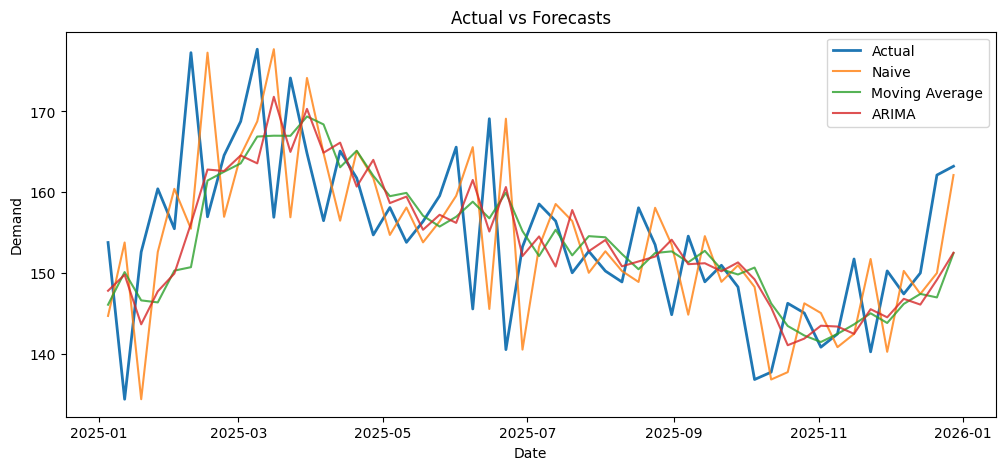

In [5]:
bilingual_title("3. 예측 실행", "3. Run forecasting models")

pred_naive = rolling_forecast_naive(train, test)
pred_ma = rolling_forecast_ma(train, test, window=4)
pred_arima = rolling_forecast_arima(train, test, order=(2,1,2))

forecast_df = pd.DataFrame({
    'Actual': test,
    'Naive': pred_naive,
    'MovingAverage': pred_ma,
    'ARIMA': pred_arima
})
display(forecast_df.head())

plt.figure(figsize=(12,5))
plt.plot(forecast_df.index, forecast_df['Actual'], label='Actual', linewidth=2)
plt.plot(forecast_df.index, forecast_df['Naive'], label='Naive', alpha=0.8)
plt.plot(forecast_df.index, forecast_df['MovingAverage'], label='Moving Average', alpha=0.8)
plt.plot(forecast_df.index, forecast_df['ARIMA'], label='ARIMA', alpha=0.8)
plt.title('Actual vs Forecasts')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

## 4. 예측 정확도 평가<br><span style='font-size:0.9em;color:#666'>4. Evaluate forecast accuracy</span>

,Model,RMSE,MAE
1,MovingAverage,8.375799,6.420734
2,ARIMA,8.449366,6.652458
0,Naive,10.795228,8.482553


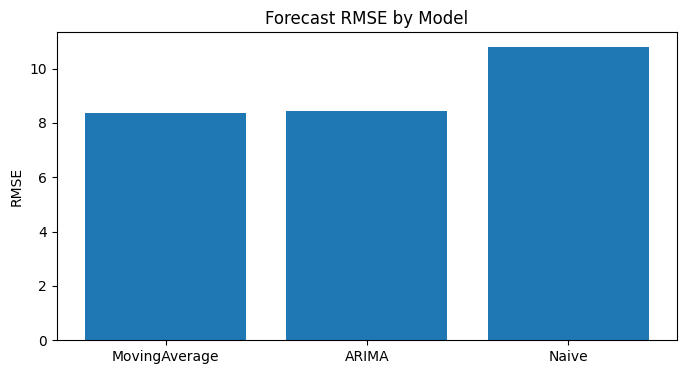

**[KR]** 예측 정확도 기준 최고 모델은 MovingAverage입니다.<br>**[EN]** The best model by forecast accuracy is MovingAverage.

In [6]:
bilingual_title("4. 예측 정확도 평가", "4. Evaluate forecast accuracy")

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))

acc = pd.DataFrame({
    'Model': ['Naive', 'MovingAverage', 'ARIMA'],
    'RMSE': [
        rmse(test, pred_naive),
        rmse(test, pred_ma),
        rmse(test, pred_arima)
    ],
    'MAE': [
        np.mean(np.abs(test - pred_naive)),
        np.mean(np.abs(test - pred_ma)),
        np.mean(np.abs(test - pred_arima))
    ]
}).sort_values('RMSE')

display(acc)

plt.figure(figsize=(8,4))
plt.bar(acc['Model'], acc['RMSE'])
plt.title('Forecast RMSE by Model')
plt.ylabel('RMSE')
plt.show()

best_forecast_model = acc.iloc[0]['Model']
bilingual_text(
    f"예측 정확도 기준 최고 모델은 {best_forecast_model}입니다.",
    f"The best model by forecast accuracy is {best_forecast_model}."
)

## 5. 예측을 주문량으로 전환<br><span style='font-size:0.9em;color:#666'>5. Convert forecasts into order quantities</span>

,Model,RMSE,AvgOrderQty,HoldingCost,ShortageCost,TotalCost
1,MovingAverage,8.375799,161.442308,825.750319,369.831311,1195.581630
2,ARIMA,8.449366,161.480769,829.095297,367.211222,1196.306519
0,Naive,10.795228,163.576923,1054.148296,395.423219,1449.571515


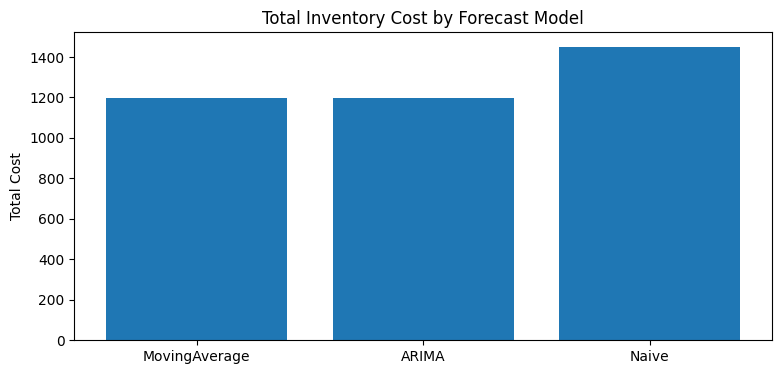

**[KR]** 총 재고비용 기준 최적 모델은 MovingAverage입니다.<br>**[EN]** The best model by total inventory cost is MovingAverage.

In [7]:
bilingual_title("5. 예측을 주문량으로 전환", "5. Convert forecasts into order quantities")

holding_cost = 2
shortage_cost = 8
critical_ratio = shortage_cost / (holding_cost + shortage_cost)
z = norm.ppf(critical_ratio)

model_map = {
    'Naive': pred_naive,
    'MovingAverage': pred_ma,
    'ARIMA': pred_arima
}

inv_rows = []
for model_name, pred in model_map.items():
    model_rmse = rmse(test, pred)
    order_qty = np.ceil(pred + z * model_rmse)
    leftover = np.maximum(order_qty.values - test.values, 0)
    shortage = np.maximum(test.values - order_qty.values, 0)
    hold_cost = holding_cost * leftover.sum()
    short_cost = shortage_cost * shortage.sum()
    total_cost = hold_cost + short_cost

    inv_rows.append({
        'Model': model_name,
        'RMSE': model_rmse,
        'AvgOrderQty': order_qty.mean(),
        'HoldingCost': hold_cost,
        'ShortageCost': short_cost,
        'TotalCost': total_cost
    })

inv_result = pd.DataFrame(inv_rows).sort_values('TotalCost')
display(inv_result)

plt.figure(figsize=(9,4))
plt.bar(inv_result['Model'], inv_result['TotalCost'])
plt.title('Total Inventory Cost by Forecast Model')
plt.ylabel('Total Cost')
plt.show()

best_decision_model = inv_result.iloc[0]['Model']
bilingual_text(
    f"총 재고비용 기준 최적 모델은 {best_decision_model}입니다.",
    f"The best model by total inventory cost is {best_decision_model}."
)

## 6. 비용 분해 시각화<br><span style='font-size:0.9em;color:#666'>6. Visualize cost decomposition</span>

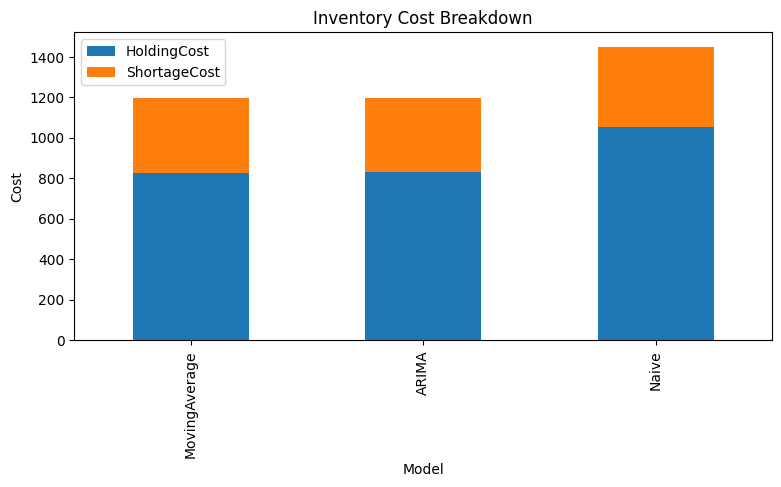

In [8]:
bilingual_title("6. 비용 분해 시각화", "6. Visualize cost decomposition")

cost_plot = inv_result.set_index('Model')[['HoldingCost', 'ShortageCost']]
cost_plot.plot(kind='bar', stacked=True, figsize=(9,4))
plt.title('Inventory Cost Breakdown')
plt.ylabel('Cost')
plt.show()

In [9]:
bilingual_title("7. 결과 해석", "7. Interpretation")

merged = acc.merge(inv_result[['Model', 'TotalCost']], on='Model')
display(merged.sort_values('RMSE'))

best_rmse = merged.sort_values('RMSE').iloc[0]['Model']
best_cost = merged.sort_values('TotalCost').iloc[0]['Model']

if best_rmse == best_cost:
    bilingual_text(
        f"이번 실험에서는 {best_rmse}가 예측 정확도와 의사결정 비용 모두에서 가장 우수했습니다.",
        f"In this experiment, {best_rmse} performed best in both forecast accuracy and decision cost."
    )
else:
    bilingual_text(
        f"이번 실험에서는 예측 정확도 최고 모델({best_rmse})과 의사결정 비용 최적 모델({best_cost})이 달랐습니다. 즉, Best Forecast ≠ Best Decision입니다.",
        f"In this experiment, the best forecasting model ({best_rmse}) was different from the best decision model ({best_cost}). In other words, Best Forecast ≠ Best Decision."
    )

## 7. 결과 해석<br><span style='font-size:0.9em;color:#666'>7. Interpretation</span>

,Model,RMSE,MAE,TotalCost
0,MovingAverage,8.375799,6.420734,1195.581630
1,ARIMA,8.449366,6.652458,1196.306519
2,Naive,10.795228,8.482553,1449.571515


**[KR]** 이번 실험에서는 MovingAverage가 예측 정확도와 의사결정 비용 모두에서 가장 우수했습니다.<br>**[EN]** In this experiment, MovingAverage performed best in both forecast accuracy and decision cost.

## 학생용 질문 / Questions for Students
1. 왜 낮은 RMSE가 항상 낮은 총비용으로 이어지지 않을까요?  
   Why does lower RMSE not always imply lower total cost?
2. holding cost와 shortage cost의 비율이 바뀌면 최적 주문량은 어떻게 달라질까요?  
   How would the optimal order quantity change if the holding/shortage cost ratio changes?
3. 안전재고를 더 크게 두면 어떤 장단점이 있습니까?  
   What are the pros and cons of larger safety stock?